In [225]:
# Import libraries
import numpy as np
import math
import random
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm # linear regression
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import scanpy as sc
import os
import SpatialproxseqClasses as SPC

#*****
mpl.rcdefaults()
# Set font to be arial
mpl.rc('font', **{'sans-serif':'Arial', 'size':12})
mpl.rcParams['mathtext.rm'] = 'sans' 
mpl.rcParams['axes.titlesize'] = 12
# Set default tick size
mpl.rcParams['xtick.major.size'] = 5.5
mpl.rcParams['ytick.major.size'] = 5.5
mpl.rcParams['xtick.minor.size'] = 2.5
mpl.rcParams['ytick.minor.size'] = 2.5
# Default legend settings
mpl.rcParams['legend.fancybox'] = False
mpl.rcParams['legend.edgecolor'] = 'k'

#to store text as text, not as path
new_rc_params = {'text.usetex': False,
                 "svg.fonttype": 'none'}
mpl.rcParams.update(new_rc_params)
#*****
# Seed number
np.random.seed(2025)
random.seed(2025)

In [226]:
#read data
adata = sc.read_h5ad('B1_cell_map_result.h5ad')
adata_filtered = sc.read_h5ad('adata_B1_rna_raw_data.h5ad')

In [227]:
spots_keep = adata_filtered.obs_names.astype(str)

# make sure spot IDs are strings
adata.var_names = adata.var_names.astype(str)
# intersection (safe)
common_spots = spots_keep.intersection(adata.var_names)
# preserve RNA spot order
common_spots = spots_keep[spots_keep.isin(common_spots)]
# subset deconvolution along VARS (spots)
adata = adata[:, common_spots].copy()

In [228]:
print("RNA spots:", adata_filtered.n_obs)
print("Deconv spots:", adata.n_vars)

# optional strict check
assert list(adata.var_names) == list(common_spots)

RNA spots: 3175
Deconv spots: 3175


In [229]:
#build cell map dataframe, number of cell type k=23
ct_prob = pd.DataFrame(
    adata.X,
    index=adata.obs['annotation_figure_1'],                   # Visium spots
    columns=adata.var_names
)

In [230]:
#build cell type proportion dataframe
# Expected number of cells per (cell type × spot)
expected_counts = ct_prob.mul(sc_ref_B1['count'], axis=0)
spot_ct_fraction = expected_counts.div(expected_counts.sum(axis=0), axis=1)

In [231]:
#optional; restrict the number of cell type in each spot
threshold = 0.01
K = 10 # k=23, no filter 

spot_frac_hybrid = spot_ct_fraction.where(
    spot_ct_fraction >= threshold,
    0.0
)

for spot in spot_frac_hybrid.columns:
    topk = spot_frac_hybrid[spot].nlargest(K).index
    spot_frac_hybrid.loc[
        ~spot_frac_hybrid.index.isin(topk), spot
    ] = 0.0

spot_frac_hybrid = spot_frac_hybrid.div(
    spot_frac_hybrid.sum(axis=0),
    axis=1
).fillna(0.0)

Visulization code

In [232]:
# Keep only spots present in both
common_spots = spot_frac_hybrid.columns.intersection(b1_tissue_position.index)

spot_frac = spot_frac_hybrid[common_spots]
b1_tissue_position = b1_tissue_position.loc[common_spots]

# Keep only in-tissue spots
mask = b1_tissue_position["in_tissue"] == 1
spot_frac = spot_frac.loc[:, mask]
b1_tissue_position = b1_tissue_position.loc[mask]

In [233]:
x = b1_tissue_position["pxl_row_in_fullres"].values.astype(float)
y = b1_tissue_position["pxl_col_in_fullres"].values.astype(float)

# Optional: flip y-axisa for plotting
x = -x

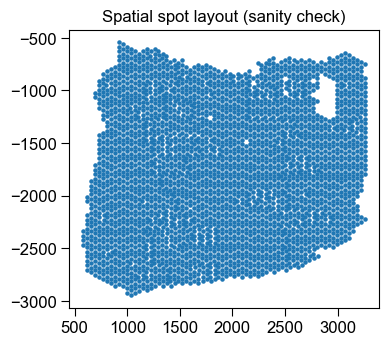

In [234]:
#test if tissue map in right orientation
plt.figure(figsize=(4, 4))
plt.scatter(y, x, s=5)
plt.gca().set_aspect("equal")
plt.title("Spatial spot layout (sanity check)")
plt.show()

In [235]:
#function block
from matplotlib.patches import Wedge

def draw_pie(ax, ratios, x, y, size=0.45):
    start = 0.0
    for frac, color in ratios:
        if frac <= 0:
            continue
        end = start + frac * 360
        wedge = Wedge(
            (x, y),
            size,
            start,
            end,
            facecolor=color,
            edgecolor="none"
        )
        ax.add_patch(wedge)
        start = end
        
def plot_spatial_pies(
    ax,
    spot_frac,
    a1_tissue_position,
    celltypes,
    colors,
    size=20,
    xlim=None,
    ylim=None,
):
    for spot in spot_frac.columns:
        if spot not in a1_tissue_position.index:
            continue

        ratios = [
            (spot_frac.loc[ct, spot], colors[ct])
            for ct in celltypes
            if spot_frac.loc[ct, spot] > 0
        ]
        if not ratios:
            continue

        draw_pie(
            ax,
            ratios,
            a1_tissue_position.loc[spot, "pxl_col_in_fullres"],
            -a1_tissue_position.loc[spot, "pxl_row_in_fullres"],
            size=size,
        )

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_aspect("equal")
    ax.axis("off")

In [236]:
celltypes = spot_frac.index.tolist()

cmaps = [
    plt.get_cmap("tab20"),
    plt.get_cmap("tab20b"),
    plt.get_cmap("tab20c")
]

palette = []
for cmap in cmaps:
    palette.extend(cmap.colors)

colors = {ct: palette[i] for i, ct in enumerate(celltypes)}


In [237]:
# Example zoom box — adjust these
# zoom region in full-resolution pixel coordinates
zoom_xlim = (1350, 1850)
zoom_ylim = (-2250, -1750)   # y already flipped

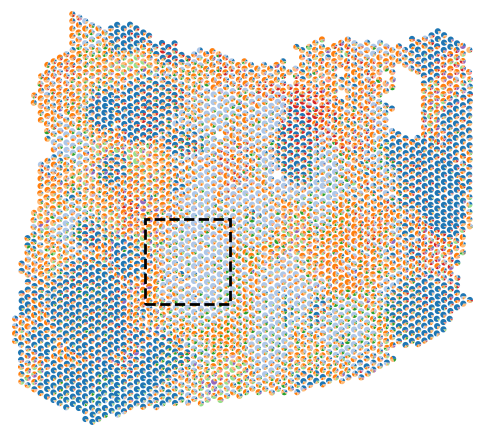

In [238]:
#full tissue with rectangle on zoom-in
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(6, 6))

# ---- full tissue pies ----
plot_spatial_pies(
    ax,
    spot_frac,
    b1_tissue_position,
    celltypes,
    colors,
    size=18,
    xlim=(
        b1_tissue_position["pxl_col_in_fullres"].min() - 30,
        b1_tissue_position["pxl_col_in_fullres"].max() + 30,
    ),
    ylim=(
        -b1_tissue_position["pxl_row_in_fullres"].max() - 30,
        -b1_tissue_position["pxl_row_in_fullres"].min() + 30,
    ),
)

# ---- draw zoom box ----
from matplotlib.patches import Rectangle

rect = Rectangle(
    (zoom_xlim[0], zoom_ylim[0]),
    zoom_xlim[1] - zoom_xlim[0],
    zoom_ylim[1] - zoom_ylim[0],
    linewidth=2,
    edgecolor="black",
    facecolor="none",
    linestyle="--"   # ⬅️ dashed line
)

ax.add_patch(rect)

plt.savefig("Figures/full_tissue_B1_decon.svg", bbox_inches="tight")
plt.show()

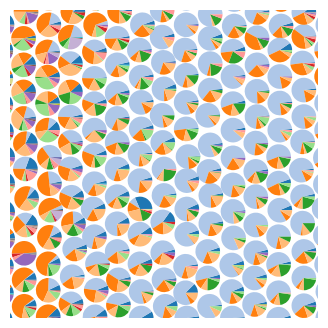

In [239]:
#zoom-in
fig, ax = plt.subplots(figsize=(4, 4))

plot_spatial_pies(
    ax,
    spot_frac,
    b1_tissue_position,
    celltypes,
    colors,
    size=20,      # ⬅️ larger pies for zoom
    xlim=zoom_xlim,
    ylim=zoom_ylim,
)

plt.savefig("Figures/zoom_region_B1.svg", bbox_inches="tight")
plt.show()

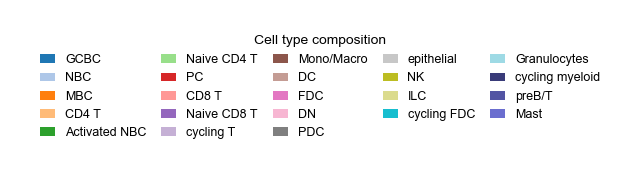

In [240]:
#plot legend separately
from matplotlib.patches import Patch
import math

legend_celltypes = list(celltypes)  # ALL cell types

legend_handles = [
    Patch(facecolor=colors[ct], label=ct)
    for ct in legend_celltypes
]

ncol = 5                      # adjust (4–6 usually good)
nrow = math.ceil(len(legend_handles) / ncol)

fig_height = 0.4 * nrow       # auto height
fig, ax = plt.subplots(figsize=(8, fig_height))
ax.axis("off")

ax.legend(
    handles=legend_handles,
    loc="center",
    ncol=ncol,
    frameon=False,
    title="Cell type composition",
    fontsize=9,
    title_fontsize=10,
    handlelength=1.2,
    columnspacing=1.2,
)

plt.savefig("Figures/Fig_legend_all_celltypes_B1.svg", bbox_inches="tight")
plt.show()

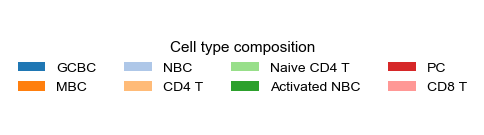

In [241]:
#show legend of top appeared cell types
from matplotlib.patches import Patch

# Choose which cell types to show in the legend
# (highly recommended: only top-used ones)
legend_celltypes = (
    spot_frac.sum(axis=1)
    .sort_values(ascending=False)
    .head(8)        # adjust number
    .index
)

legend_handles = [
    Patch(facecolor=colors[ct], label=ct)
    for ct in legend_celltypes
]

fig, ax = plt.subplots(figsize=(6, 1.5))
ax.axis("off")

ax.legend(
    handles=legend_handles,
    loc="center",
    ncol=4,                    # number of columns
    frameon=False,
    title="Cell type composition",
    fontsize=10,
    title_fontsize=11,
)

plt.savefig("Figures/Fig_legend_main_celltypes_B1.svg", bbox_inches="tight")

plt.show()

cell type proportion in each cluster

In [242]:
# Intersection (spots present in both)
common_spots = spot_frac.columns.intersection(b1_cluster.index)

spot_frac_aligned = spot_frac.loc[:, common_spots]
b1_cluster_aligned = b1_cluster.loc[common_spots]

spot_to_cluster = b1_cluster_aligned["mrna_annotation"]

In [243]:
spot_frac_by_cluster = (
    spot_frac_aligned
    .T
    .assign(cluster=spot_to_cluster)
    .groupby("cluster")
    .mean()
    .T
)

In [244]:
celltypes = spot_frac.index.tolist()

cmaps = [
    plt.get_cmap("tab20"),
    plt.get_cmap("tab20b"),
    plt.get_cmap("tab20c")
]

palette = []
for cmap in cmaps:
    palette.extend(cmap.colors)

colors = {ct: palette[i] for i, ct in enumerate(celltypes)}

df = spot_frac_by_cluster.copy()

# Normalize columns to sum to 100%
df = df.div(df.sum(axis=0), axis=1) * 100

In [245]:
spot_to_cluster.unique()


array(['Epithelial-basal cell', 'Non-GC follicles', 'Dark zone',
       'Light zone', 'T:B border', 'Epithelial-crypt', 'Mantle zone'],
      dtype=object)

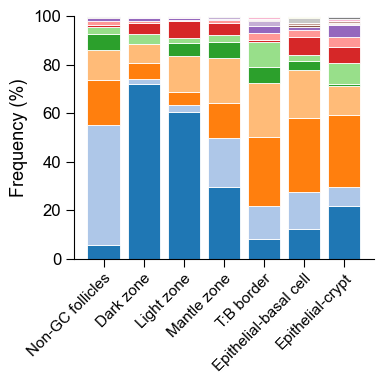

In [246]:
# --- Define desired column order ---
desired_order = [
    "Non-GC follicles",
    "Dark zone",
    "Light zone",
    "Mantle zone",
    "T:B border",
    "Epithelial-basal cell",
    "Epithelial-crypt"
]

# --- Reorder dataframe ---
df = df[desired_order]

# --- Plot ---
clusters = df.columns.tolist()
x = np.arange(len(clusters))

fig, ax = plt.subplots(figsize=(4, 4))

bottom = np.zeros(len(clusters))

for ct in celltypes:
    values = df.loc[ct].values
    ax.bar(
        x,
        values,
        bottom=bottom,
        color=colors[ct],
        edgecolor="white",
        linewidth=0.6,
        label=ct
    )
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(clusters, fontsize=11)
plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor"
)

ax.set_ylabel("Frequency (%)", fontsize=13)
ax.set_ylim(0, 100)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("Figures/frequency_cell_type_per_cluster_B1.svg", bbox_inches="tight")
plt.show()


Colocalization analysis of cell type

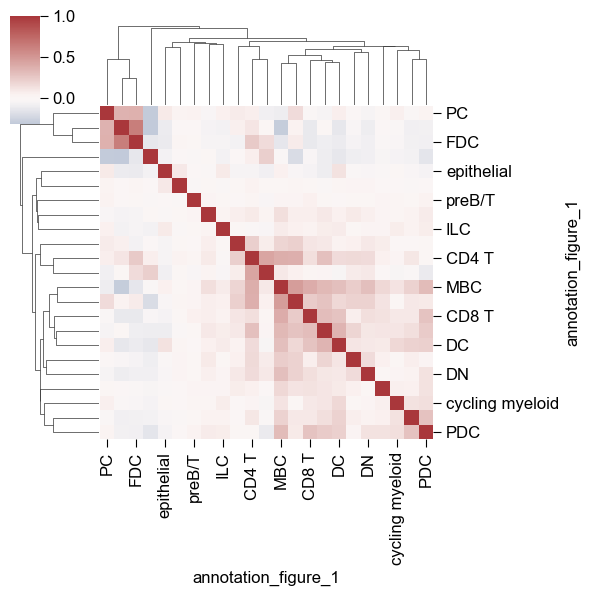

In [247]:
import seaborn as sns
corr_ct = ct_prob.T.corr(method='pearson')
sns.clustermap(corr_ct, cmap='vlag', center=0, figsize=(6, 6))

link protein interactions with specific cell type

In [248]:

from scipy.stats import pearsonr, spearmanr

def correlate_pla_with_celltypes(
    pla_pair,
    pla_weight_df,
    celltype_df,
    method="pearson",      # "pearson" or "spearman"
    plot=True,
    cmap="viridis",
    center=0,
    sort_by="corr",        # "corr" or "abs"
    compute_p=True,        # compute p-values (recommended)
    annot="corr",          # "corr", "p", "both", or False
    save=False,
    outdir=".",
    dpi=300
):
    """
    Correlate a PLA interaction vector with cell-type signals (rows in celltype_df),
    rank correlations, and optionally plot a heatmap.

    Parameters
    ----------
    pla_pair : str
        Row key in pla_weight_df.
    pla_weight_df : pd.DataFrame
        Rows = PLA pairs, cols = spots.
    celltype_df : pd.DataFrame
        Rows = cell types, cols = spots.
    method : str
        "pearson" (R) or "spearman" (rho).
    sort_by : str
        "corr" sorts by signed correlation, "abs" sorts by absolute magnitude.
    compute_p : bool
        If True, compute p-values using scipy (pearsonr/spearmanr).
    annot : str|bool
        "corr" to annotate correlation only, "p" for p only, "both" for "corr\np",
        or False to disable annotations.

    Returns
    -------
    corr_df : pd.DataFrame
        Correlation values (index=cell types, column=pla_pair).
    p_df : pd.DataFrame or None
        P-values (same shape) if compute_p else None.
    """

    # --- Extract PLA vector ---
    if pla_pair not in pla_weight_df.index:
        raise KeyError(f"pla_pair '{pla_pair}' not found in pla_weight_df.index")
    pla_vec = pla_weight_df.loc[pla_pair]

    # --- Align spots ---
    common_spots = celltype_df.columns.intersection(pla_vec.index)
    if len(common_spots) == 0:
        raise ValueError("No overlapping spots between PLA and cell-type data.")

    pla_vec = pla_vec.loc[common_spots]
    X = celltype_df.loc[:, common_spots]

    method = method.lower()
    if method not in {"pearson", "spearman"}:
        raise ValueError("method must be 'pearson' or 'spearman'")

    # --- Compute correlations (fast via pandas) ---
    corr = X.apply(lambda row: row.corr(pla_vec, method=method), axis=1)
    corr_df = corr.to_frame(name=pla_pair)

    # --- Compute p-values (optional, via scipy) ---
    p_df = None
    if compute_p:
        pvals = []
        for ct in X.index:
            xv = X.loc[ct].astype(float).values
            yv = pla_vec.astype(float).values
            ok = np.isfinite(xv) & np.isfinite(yv)
            if ok.sum() < 3:
                pvals.append(np.nan)
                continue
            if method == "pearson":
                r, p = pearsonr(xv[ok], yv[ok])
            else:
                r, p = spearmanr(xv[ok], yv[ok])
            pvals.append(p)
        p_df = pd.DataFrame({pla_pair: pvals}, index=X.index)

    # --- Sort ---
    if sort_by == "abs":
        corr_df = corr_df.reindex(corr_df[pla_pair].abs().sort_values(ascending=False).index)
        if p_df is not None:
            p_df = p_df.reindex(corr_df.index)
    else:  # "corr"
        corr_df = corr_df.sort_values(by=pla_pair, ascending=False)
        if p_df is not None:
            p_df = p_df.reindex(corr_df.index)

    # --- Plot ---
    if plot:
        # annotations
        annot_data = None
        if annot and annot is not False:
            if annot == "corr":
                annot_data = corr_df.round(2).astype(str).values
            elif annot == "p":
                if p_df is None:
                    raise ValueError("annot='p' requires compute_p=True")
                annot_data = p_df.applymap(lambda v: "NA" if pd.isna(v) else f"{v:.1e}").values
            elif annot == "both":
                if p_df is None:
                    raise ValueError("annot='both' requires compute_p=True")
                corr_txt = corr_df.round(2).astype(str).values
                p_txt = p_df.applymap(lambda v: "NA" if pd.isna(v) else f"{v:.1e}").values
                annot_data = (corr_txt + "\n" + p_txt)
            else:
                raise ValueError("annot must be 'corr', 'p', 'both', or False")

        plt.figure(figsize=(4, max(1.6, len(corr_df) * 0.26)))
        sns.heatmap(
            corr_df,
            annot=annot_data if annot_data is not None else False,
            fmt="",
            cmap=cmap,
            center=center,
            cbar=True
        )

        label = "R" if method == "pearson" else "ρ"
        plt.title(f"{label} correlation (ranked)\nPLA {pla_pair}")
        plt.tight_layout()

        if save:
            os.makedirs(outdir, exist_ok=True)
            safe_pair = str(pla_pair).replace(":", "_").replace("/", "_")
            fname = f"{safe_pair}_{method}_celltype_corr.svg"
            plt.savefig(os.path.join(outdir, fname), dpi=dpi, bbox_inches="tight")

        plt.show()

    return corr_df, p_df


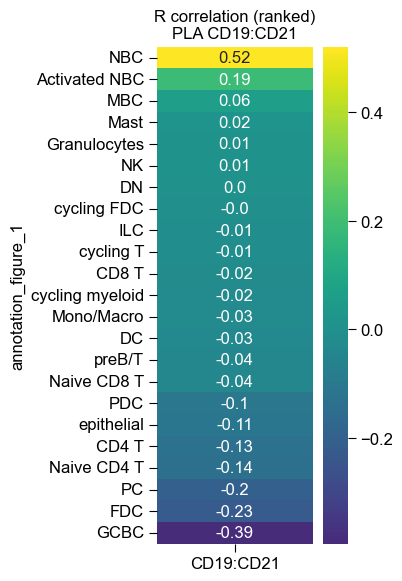

In [249]:
corr_df, p_df = correlate_pla_with_celltypes(
    pla_pair="CD19:CD21",
    pla_weight_df=b1_pla_weight,
    celltype_df=spot_frac,
    method="pearson",
    sort_by="corr",
    compute_p=True,
    annot="corr",
    save=True,
    outdir="./celltype_corr_B1"
)


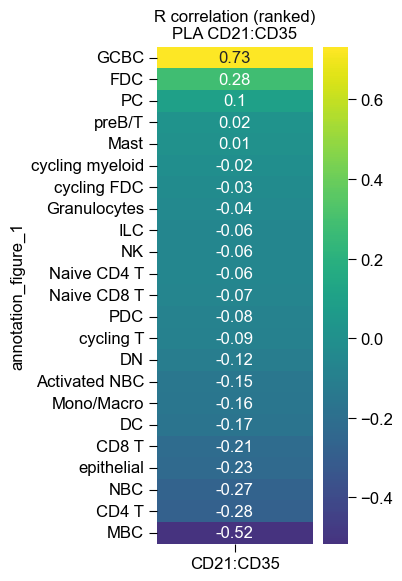

In [250]:
corr_df, p_df = correlate_pla_with_celltypes(
    pla_pair="CD21:CD35",
    pla_weight_df=b1_pla_weight,
    celltype_df=spot_frac,
    method="pearson",
    sort_by="corr",
    compute_p=True,
    annot="corr",
    save=True,
    outdir="./celltype_corr_B1"
)


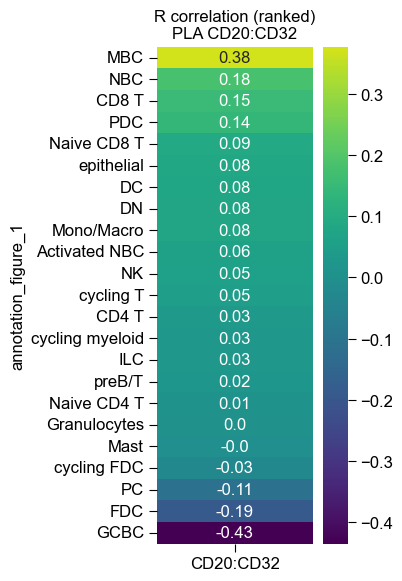

In [251]:
corr_df, p_df = correlate_pla_with_celltypes(
    pla_pair="CD20:CD32",
    pla_weight_df=b1_pla_weight,
    celltype_df=spot_frac,
    method="pearson",
    sort_by="corr",
    compute_p=True,
    annot="corr",
    save=True,
    outdir="./celltype_corr_B1"
)


In [252]:
#Link protein interaction strength with cell type across all spots

In [253]:
# spot -> region label (e.g., "Non-GC follicles")
spot_to_cluster = b1_cluster["mrna_annotation"]
spot_to_cluster.index = spot_to_cluster.index.astype(str)


In [286]:

def scatter_global_celltype(
    pla_pair,
    cell_type,
    pla_weight_df,
    cell_df,
    method="pearson",          # "pearson" or "spearman"
    figsize=(3, 3),
    min_spots=30,
    add_reg_line=True,
    save_fig=False,
    save_data=False,
    outdir=".",
    dpi=300,
):
    """
    Scatter plot of cell-type signal (x) vs PLA signal (y) across spots,
    compute correlation (Pearson R or Spearman rho), optionally save figure and data.

    Returns
    -------
    (r, p, n, df_used) or None if insufficient data
      - r: correlation coefficient (R or rho)
      - p: p-value
      - n: number of valid spots used
      - df_used: DataFrame with x/y values used in the plot
    """

    # --- extract vectors ---
    if pla_pair not in pla_weight_df.index:
        raise KeyError(f"pla_pair '{pla_pair}' not found in pla_weight_df.index")
    if cell_type not in cell_df.index:
        raise KeyError(f"cell_type '{cell_type}' not found in cell_df.index")

    y = pla_weight_df.loc[pla_pair]
    x = cell_df.loc[cell_type]

    # --- align ---
    common = x.index.astype(str).intersection(y.index.astype(str))
    if len(common) < min_spots:
        return None

    x_aligned = x.loc[common].astype(float)
    y_aligned = y.loc[common].astype(float)

    ok = np.isfinite(x_aligned.values) & np.isfinite(y_aligned.values)
    n = int(ok.sum())
    if n < min_spots:
        return None

    xv = x_aligned.values[ok]
    yv = y_aligned.values[ok]

    # --- correlation ---
    method = method.lower()
    if method == "pearson":
        r, p = pearsonr(xv, yv)
        r_label = "R"
    elif method == "spearman":
        r, p = spearmanr(xv, yv)
        r_label = "ρ"
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")

    # data used (for saving / reproducibility)
    df_used = pd.DataFrame({
        "spot": x_aligned.index.astype(str).values[ok],
        "x_celltype": xv,
        "y_pla": yv
    })

    # --- plot ---
    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(xv, yv, s=10, alpha=0.6)

    if add_reg_line:
        # avoid polyfit crash if x is constant
        if np.nanstd(xv) > 0:
            coef = np.polyfit(xv, yv, 1)
            xs = np.linspace(np.min(xv), np.max(xv), 100)
            ys = coef[0] * xs + coef[1]
            ax.plot(xs, ys, color="black", linewidth=1)

    ax.set_xlabel(f"{cell_type} fraction")
    ax.set_ylabel(f"Fractional overlap score \nof {pla_pair}")
    ax.set_title(f"{r_label}={r:.2f}, p={p:.1e}, n={n}")

    fig.tight_layout()

    # --- save outputs ---
    if save_fig or save_data:
        os.makedirs(outdir, exist_ok=True)
        safe_pair = str(pla_pair).replace(":", "_").replace("/", "_")
        safe_cell = str(cell_type).replace(" ", "_").replace("/", "_")

    if save_fig:
        fig_path = os.path.join(outdir, f"{safe_pair}__{safe_cell}_{method}_scatter.svg")
        fig.savefig(fig_path, dpi=dpi, bbox_inches="tight")

    if save_data:
        data_path = os.path.join(outdir, f"{safe_pair}__{safe_cell}_{method}_scatter_data.csv")
        df_used.to_csv(data_path, index=False)

    plt.show()

    return r, p, n, df_used


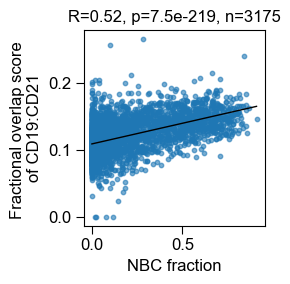

In [287]:
r, p, n, df_used = scatter_global_celltype(
    pla_pair="CD19:CD21",
    cell_type="NBC",
    pla_weight_df=b1_pla_weight,
    cell_df=spot_frac,
    method="pearson",
    save_fig=True,
    save_data=True,
    outdir="./scatter_outputs_B1"
)


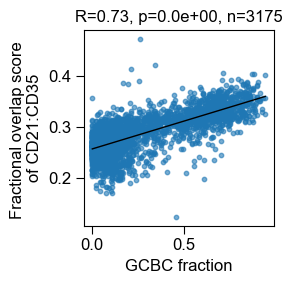

In [289]:
r, p, n, df_used = scatter_global_celltype(
    pla_pair="CD21:CD35",
    cell_type="GCBC",
    pla_weight_df=b1_pla_weight,
    cell_df=spot_frac,
    method="pearson",
    save_fig=True,
    save_data=True,
    outdir="./scatter_outputs_B1"
)

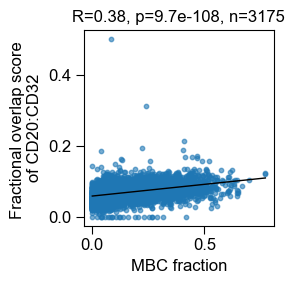

In [257]:
r, p, n, df_used = scatter_global_celltype(
    pla_pair="CD20:CD32",
    cell_type="MBC",
    pla_weight_df=b1_pla_weight,
    cell_df=spot_frac,
    method="pearson",
    save_fig=True,
    save_data=True,
    outdir="./scatter_outputs_B1"
)

In [258]:
#Link protein interaction strength with cell type wintin a cluster

In [259]:

def scatter_within_region(
    pla_pair: str,
    cell_type: str,
    pla_weight_df: pd.DataFrame,
    cell_df: pd.DataFrame,
    spot_to_cluster: pd.Series,
    region_name: str = "Non-GC follicles",
    min_spots: int = 30,
    log1p_pla: bool = True,
    method: str = "pearson",      # "pearson" or "spearman"
    add_reg_line: bool = True,
    save_fig: bool = False,
    save_data: bool = False,
    outdir: str = ".",
    dpi: int = 300,
):
    """
    Scatter plot and correlation within a specified region (subset of spots).

    x: cell-type fraction (or signal)
    y: PLA signal (optionally log1p transformed)

    method:
      - "pearson": reports R and p-value (linear association)
      - "spearman": reports rho and p-value (rank/monotonic association)

    Returns: (r, p, n, df_used)
    """

    # --- region spot IDs ---
    region_spots = spot_to_cluster[spot_to_cluster == region_name].index.astype(str)

    # --- extract and normalize indices to string ---
    if pla_pair not in pla_weight_df.index:
        raise KeyError(f"pla_pair '{pla_pair}' not found in pla_weight_df.index")
    if cell_type not in cell_df.index:
        raise KeyError(f"cell_type '{cell_type}' not found in cell_df.index")

    y = pla_weight_df.loc[pla_pair].copy()
    y.index = y.index.astype(str)

    x = cell_df.loc[cell_type].copy()
    x.index = x.index.astype(str)

    # --- intersect spots ---
    common = x.index.intersection(y.index).intersection(region_spots)
    if len(common) < min_spots:
        raise ValueError(f"Too few spots for scatter: {len(common)} < {min_spots}")

    xv = x.loc[common].astype(float).values
    yv = y.loc[common].astype(float).values
    if log1p_pla:
        yv = np.log1p(yv)

    ok = np.isfinite(xv) & np.isfinite(yv)
    n = int(ok.sum())
    if n < min_spots:
        raise ValueError(f"Too few finite spots for scatter: {n} < {min_spots}")

    xv = xv[ok]
    yv = yv[ok]

    # --- correlation ---
    method = method.lower()
    if method == "pearson":
        r, p = pearsonr(xv, yv)
        r_label = "R"
    elif method == "spearman":
        r, p = spearmanr(xv, yv)
        r_label = "ρ"
    else:
        raise ValueError("method must be 'pearson' or 'spearman'")

    # --- data used (for saving) ---
    df_used = pd.DataFrame({
        "spot": pd.Index(common).astype(str).values[ok],
        "x_celltype": xv,
        "y_pla": yv,
        "region": region_name,
        "pla_pair": pla_pair,
        "cell_type": cell_type
    })

    # --- plot ---
    fig, ax = plt.subplots(figsize=(3.5, 3.5))
    ax.scatter(xv, yv, s=12, alpha=0.8)

    # regression line (optional)
    if add_reg_line and np.nanstd(xv) > 0:
        coef = np.polyfit(xv, yv, 1)
        xs = np.linspace(np.min(xv), np.max(xv), 100)
        ys = coef[0] * xs + coef[1]
        ax.plot(xs, ys, color="black", linewidth=1)

    ax.set_xlabel(f"{cell_type} fraction")
    ax.set_ylabel(f"log1p(PLA {pla_pair})" if log1p_pla else f"Fractional overlap score of {pla_pair}")
    ax.set_title(f"{region_name}: {r_label}={r:.2f}, p={p:.1e} (n={n})")

    fig.tight_layout()

    # --- save outputs ---
    if save_fig or save_data:
        os.makedirs(outdir, exist_ok=True)
        safe_pair = str(pla_pair).replace(":", "_").replace("/", "_")
        safe_cell = str(cell_type).replace(" ", "_").replace("/", "_")
        safe_region = str(region_name).replace(" ", "_").replace("/", "_")

    if save_fig:
        fig_path = os.path.join(outdir, f"{safe_pair}__{safe_cell}__{safe_region}_{method}_scatter.svg")
        fig.savefig(fig_path, dpi=dpi, bbox_inches="tight")

    if save_data:
        data_path = os.path.join(outdir, f"{safe_pair}__{safe_cell}__{safe_region}_{method}_scatter_data.csv")
        df_used.to_csv(data_path, index=False)

    plt.show()

    return r, p, n, df_used


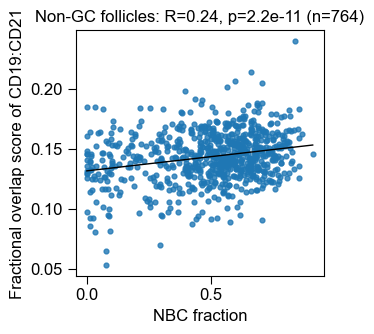

In [260]:
r, p, n, df_used = scatter_within_region(
    pla_pair="CD19:CD21",
    cell_type="NBC",
    pla_weight_df=b1_pla_weight,
    cell_df=spot_frac,
    spot_to_cluster=spot_to_cluster,
    region_name="Non-GC follicles",
    method="pearson",
    log1p_pla=False,
    save_fig=True,
    save_data=True,
    outdir="./within_region_scatter_B1"
)


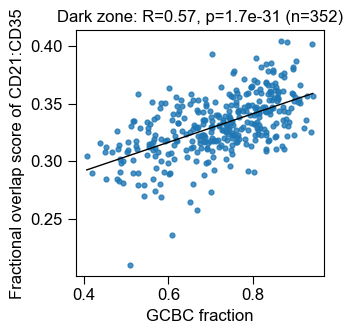

In [261]:
r, p, n, df_used = scatter_within_region(
    pla_pair="CD21:CD35",
    cell_type="GCBC",
    pla_weight_df=b1_pla_weight,
    cell_df=spot_frac,
    spot_to_cluster=spot_to_cluster,
    region_name="Dark zone",
    method="pearson",
    log1p_pla=False,
    save_fig=True,
    save_data=True,
    outdir="./within_region_scatter_B1"
)


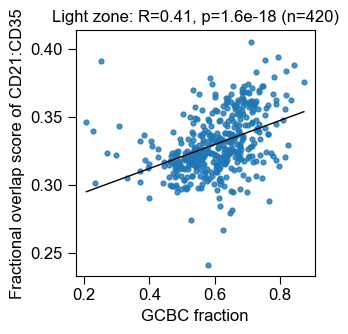

In [262]:
r, p, n, df_used = scatter_within_region(
    pla_pair="CD21:CD35",
    cell_type="GCBC",
    pla_weight_df=b1_pla_weight,
    cell_df=spot_frac,
    spot_to_cluster=spot_to_cluster,
    region_name="Light zone",
    method="pearson",
    log1p_pla=False,
    save_fig=True,
    save_data=True,
    outdir="./within_region_scatter_B1"
)


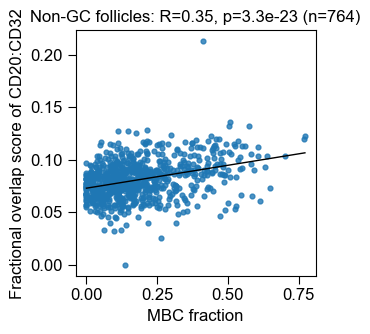

In [263]:
r, p, n, df_used = scatter_within_region(
    pla_pair="CD20:CD32",
    cell_type="MBC",
    pla_weight_df=b1_pla_weight,
    cell_df=spot_frac,
    spot_to_cluster=spot_to_cluster,
    region_name="Non-GC follicles",
    method="pearson",
    save_fig=True,
    save_data=True,
    log1p_pla=False,
    outdir="./within_region_scatter_B1"
)


In [264]:
# Evaluate the distribution of one cell-type fraction (e.g., MBC) across all Visium spots (optionally within a region).

In [265]:


def summarize_fraction(v: np.ndarray) -> pd.Series:
    v = v[np.isfinite(v)]
    return pd.Series({
        "n": v.size,
        "min": float(np.min(v)) if v.size else np.nan,
        "p1": float(np.quantile(v, 0.01)) if v.size else np.nan,
        "p5": float(np.quantile(v, 0.05)) if v.size else np.nan,
        "p10": float(np.quantile(v, 0.10)) if v.size else np.nan,
        "median": float(np.median(v)) if v.size else np.nan,
        "mean": float(np.mean(v)) if v.size else np.nan,
        "p90": float(np.quantile(v, 0.90)) if v.size else np.nan,
        "p95": float(np.quantile(v, 0.95)) if v.size else np.nan,
        "p99": float(np.quantile(v, 0.99)) if v.size else np.nan,
        "max": float(np.max(v)) if v.size else np.nan,
    })

def get_fraction_vector(
    cell_df: pd.DataFrame,
    cell_type: str,
    spot_to_cluster: pd.Series | None = None,
    region_name: str | None = None,
    min_spots: int = 30,
) -> pd.Series:
    """
    Returns a Series indexed by spot: fraction of cell_type.
    If region_name is provided, subset to that region based on spot_to_cluster.
    """
    if cell_type not in cell_df.index:
        raise ValueError(f"{cell_type} not found in cell_df.index. Available examples: {list(cell_df.index[:5])}")

    x = cell_df.loc[cell_type].copy()
    x.index = x.index.astype(str)

    if region_name is not None:
        if spot_to_cluster is None:
            raise ValueError("region_name provided but spot_to_cluster is None.")
        spot_to_cluster = spot_to_cluster.copy()
        spot_to_cluster.index = spot_to_cluster.index.astype(str)
        region_spots = spot_to_cluster[spot_to_cluster == region_name].index
        x = x.loc[x.index.intersection(region_spots)]

    x = x.astype(float)
    x = x[np.isfinite(x)]

    if x.shape[0] < min_spots:
        raise ValueError(f"Too few spots after subsetting: {x.shape[0]} < {min_spots}")

    return x


def plot_fraction_distribution(
    cell_df: pd.DataFrame,
    cell_type: str = "MBC",
    spot_to_cluster: pd.Series | None = None,
    region_name: str | None = None,
    bins: int = 60,
    show_cdf: bool = True,
    annotate_thresholds: tuple[float, ...] = (0.2, 0.4, 0.6),
    hist_figsize: tuple[float, float] = (4, 3),      # ⬅️ NEW
    cdf_figsize: tuple[float, float] = (3.5, 2.8),   # ⬅️ NEW (smaller 2nd figure)
):
    """
    Plots:
      1) Histogram of fractions
      2) (Optional) ECDF/CDF
    Also prints a summary table of quantiles.
    """
    x = get_fraction_vector(cell_df, cell_type, spot_to_cluster, region_name)

    # ---- summary stats ----
    stats = summarize_fraction(x.values)
    print(f"\n=== {cell_type} fraction distribution"
          f"{' (within '+region_name+')' if region_name else ' (all spots)'} ===")
    print(stats.to_string())

    # ---- histogram ----
    plt.figure(figsize=hist_figsize)   # ⬅️ CHANGED
    plt.hist(x.values, bins=bins)
    plt.xlabel(f"{cell_type} fraction")
    plt.ylabel("Number of spots")
    title = f"{cell_type} fraction distribution"
    title += f"\nwithin {region_name}" if region_name else "\n(all spots)"
    plt.title(title)

    for t in annotate_thresholds:
        plt.axvline(t, linewidth=1)
        pct = 100.0 * (x.values >= t).mean()
        plt.text(t, plt.ylim()[1] * 0.95, f">={t:.1f}: {pct:.1f}%", rotation=90, va="top")

    plt.tight_layout()
    plt.show()

    # ---- ECDF / CDF ----
    if show_cdf:
        xs = np.sort(x.values)
        cdf = np.arange(1, len(xs) + 1) / len(xs)

        plt.figure(figsize=cdf_figsize)   # ⬅️ CHANGED
        plt.plot(xs, cdf)
        plt.xlabel(f"{cell_type} fraction")
        plt.ylabel("CDF (fraction of spots ≤ x)")
        title = f"{cell_type} fraction CDF"
        title += f"\nwithin {region_name}" if region_name else "\n(all spots)"
        plt.title(title)

        for t in annotate_thresholds:
            exceed = 1.0 - np.mean(xs <= t)
            plt.axvline(t, linewidth=1)
            plt.text(t, 0.02, f">{t:.1f}: {exceed*100:.1f}%", rotation=90, va="bottom")

        plt.tight_layout()
        plt.show()

    return x, stats



def fraction_by_region_boxplot(
    cell_df: pd.DataFrame,
    cell_type: str,
    spot_to_cluster: pd.Series,
    min_spots_per_region: int = 30,
    order: list[str] | None = None,
):
    """
    Boxplot of cell_type fraction across regions/clusters (mrna_annotation).
    This will show whether any region is MBC-enriched (even if not exclusive).
    """
    if spot_to_cluster is None:
        raise ValueError("spot_to_cluster is required for by-region plot.")

    x = cell_df.loc[cell_type].copy()
    x.index = x.index.astype(str)

    stc = spot_to_cluster.copy()
    stc.index = stc.index.astype(str)

    common = x.index.intersection(stc.index)
    df = pd.DataFrame({
        "spot": common,
        "fraction": x.loc[common].astype(float).values,
        "region": stc.loc[common].values
    }).dropna()

    # filter small regions
    vc = df["region"].value_counts()
    keep = vc[vc >= min_spots_per_region].index
    df = df[df["region"].isin(keep)]

    # order regions by median fraction if not specified
    if order is None:
        order = (df.groupby("region")["fraction"].median()
                   .sort_values(ascending=False).index.tolist())

    plt.figure(figsize=(4, 3))
    # simple matplotlib boxplot per region
    data = [df.loc[df["region"] == r, "fraction"].values for r in order]
    plt.boxplot(data, labels=order, showfliers=False)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(f"{cell_type} fraction")
    plt.title(f"{cell_type} fraction by region (mrna_annotation)")
    plt.tight_layout()
    plt.show()

    # print top regions by median
    med = df.groupby("region")["fraction"].median().sort_values(ascending=False)
    print("\nTop regions by median fraction:")
    print(med.head(10).to_string())

    return df

# --------------------------
# How to run on your objects
# --------------------------

# If you haven't defined spot_to_cluster yet:
# spot_to_cluster = a1_cluster["mrna_annotation"]



=== MBC fraction distribution (all spots) ===
n         3175.000000
min          0.000000
p1           0.000000
p5           0.000000
p10          0.021515
median       0.175012
mean         0.198497
p90          0.412667
p95          0.466022
p99          0.575233
max          0.772091


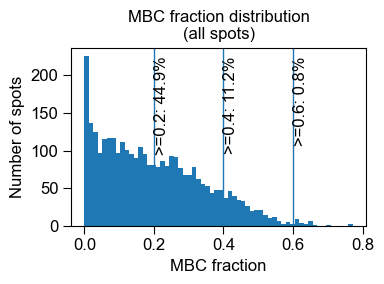

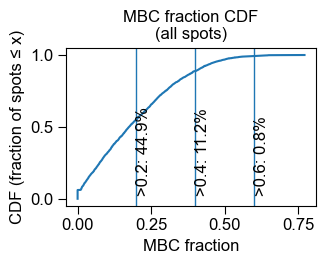

In [266]:

# 1) Distribution across ALL spots
x_all, stats_all = plot_fraction_distribution(
    cell_df=spot_frac,          # your fractions (cell_type x spot)
    cell_type="MBC",
    spot_to_cluster=None,
    region_name=None,
    bins=60,
    show_cdf=True,
    annotate_thresholds=(0.2, 0.4, 0.6)
)



=== NBC fraction distribution (all spots) ===
n         3175.000000
min          0.000000
p1           0.000000
p5           0.000000
p10          0.000000
median       0.090428
mean         0.196572
p90          0.583812
p95          0.674225
p99          0.786800
max          0.909418


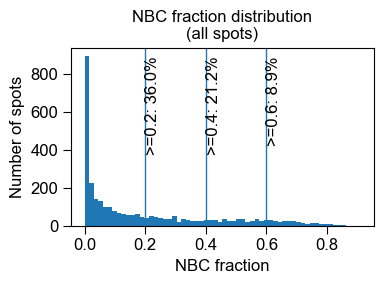

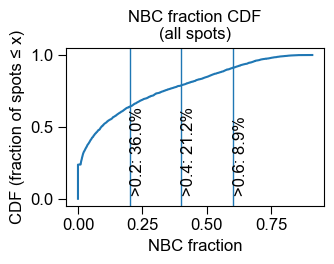

In [267]:

# 1) Distribution across ALL spots
x_all, stats_all = plot_fraction_distribution(
    cell_df=spot_frac,          # your fractions (cell_type x spot)
    cell_type="NBC",
    spot_to_cluster=None,
    region_name=None,
    bins=60,
    show_cdf=True,
    annotate_thresholds=(0.2, 0.4, 0.6)
)

In [279]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def fraction_by_region_box(
    cell_df: pd.DataFrame,                 # rows=cell types, cols=spots
    cell_type: str,                        # e.g., "MBC"
    spot_to_cluster: pd.Series,            # index=spots, values=cluster/region labels
    min_spots_per_region: int = 30,
    order: list[str] | None = None,
    figsize: tuple[float, float] = (4, 3.5),
    show_points: bool = True,
    point_size: float = 2,
    point_alpha: float = 0.35,
    jitter: float = 0.25,
    save_fig: bool = False,
    outdir: str = ".",
    dpi: int = 300,
):
    """
    Boxplot + jitter (stripplot) of cell_type fraction across clusters/regions.
    Filters clusters with < min_spots_per_region spots.
    """

    if cell_type not in cell_df.index:
        raise ValueError(f"{cell_type} not found in cell_df.index")

    # --- extract vectors ---
    x = cell_df.loc[cell_type].copy()
    x.index = x.index.astype(str)

    stc = spot_to_cluster.copy()
    stc.index = stc.index.astype(str)

    # --- align ---
    common = x.index.intersection(stc.index)
    df = pd.DataFrame({
        "fraction": x.loc[common].astype(float).values,
        "cluster": stc.loc[common].astype(str).values
    }).dropna()

    # --- filter small clusters ---
    vc = df["cluster"].value_counts()
    keep = vc[vc >= min_spots_per_region].index
    df = df[df["cluster"].isin(keep)].copy()

    if df.empty:
        raise ValueError("No clusters left after filtering.")

    # --- order clusters ---
    if order is None:
        order = (
            df.groupby("cluster")["fraction"]
              .median()
              .sort_values(ascending=False)
              .index.tolist()
        )
    else:
        order = [c for c in order if c in df["cluster"].unique()]

    # --- plot: box + jitter ---
    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=df,
        x="cluster",
        y="fraction",
        order=order,
        showfliers=False,
        linewidth=1,
        ax=ax
    )

    if show_points:
        sns.stripplot(
            data=df,
            x="cluster",
            y="fraction",
            order=order,
            size=point_size,
            alpha=point_alpha,
            jitter=jitter,
            ax=ax
        )

    ax.set_xticklabels(order, rotation=45, ha="right")
    ax.set_ylabel(f"{cell_type} fraction")
    ax.set_title(
        f"{cell_type} fraction across clusters"
    )

    fig.tight_layout()

    if save_fig:
        os.makedirs(outdir, exist_ok=True)
        safe_cell = str(cell_type).replace(" ", "_").replace("/", "_")
        fig.savefig(
            os.path.join(outdir, f"{safe_cell}_fraction_box_B1.svg"),
            dpi=dpi,
            bbox_inches="tight"
        )

    plt.show()


/var/folders/zq/r1fxzh5j34100gjpvnw5chf40000gp/T/ipykernel_44223/4107434466.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha="right")


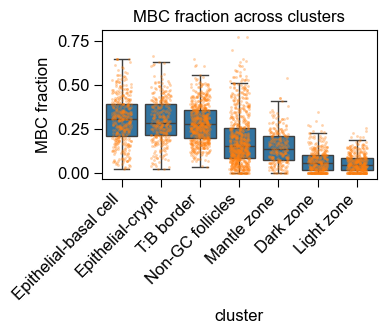

In [280]:
fraction_by_region_box(
    cell_df=spot_frac,
    cell_type="MBC",
    spot_to_cluster=spot_to_cluster,
    save_fig=True,
    outdir="./figures"
)



/var/folders/zq/r1fxzh5j34100gjpvnw5chf40000gp/T/ipykernel_44223/4107434466.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha="right")


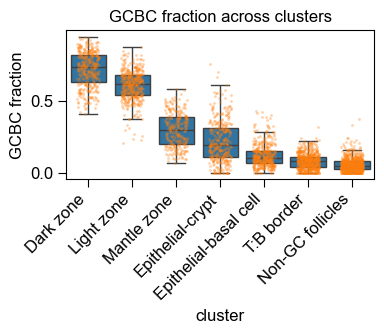

In [281]:
fraction_by_region_box(
    cell_df=spot_frac,
    cell_type="GCBC",
    spot_to_cluster=spot_to_cluster,
    save_fig=True,
    outdir="./figures"
)


/var/folders/zq/r1fxzh5j34100gjpvnw5chf40000gp/T/ipykernel_44223/4107434466.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha="right")


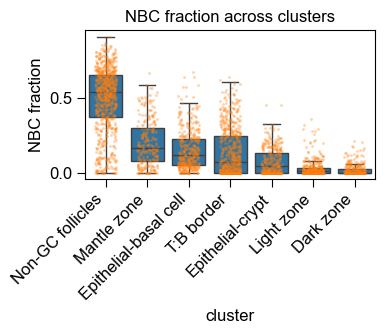

In [282]:
fraction_by_region_box(
    cell_df=spot_frac,
    cell_type="NBC",
    spot_to_cluster=spot_to_cluster,
    save_fig=True,
    outdir="./figures"
)


In [272]:


def plot_spatial_continuous(
    values: pd.Series,           # index=spot, value=continuous (e.g. MBC fraction)
    tissue_pos: pd.DataFrame,    # Visium tissue_positions
    title: str,
    cmap="viridis",
    vmin=0,
    vmax=1,
    s=3,
    save_fig: bool = False,
    outdir: str = ".",
    dpi: int = 300,
):
    idx = values.index.astype(str)
    tp = tissue_pos.loc[idx]

    x = tp["pxl_col_in_fullres"].values
    y = -tp["pxl_row_in_fullres"].values  # flip y

    fig, ax = plt.subplots(figsize=(3.5, 3.5))
    sc = ax.scatter(
        x, y,
        c=values.values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        s=s
    )
    ax.set_aspect("equal")
    ax.axis("off")

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(title)

    ax.set_title(title)
    fig.tight_layout()

    # --- save figure ---
    if save_fig:
        os.makedirs(outdir, exist_ok=True)
        safe_title = str(title).replace(" ", "_").replace("/", "_")
        fig.savefig(
            os.path.join(outdir, f"{safe_title}_spatial.svg"),
            dpi=dpi,
            bbox_inches="tight"
        )

    plt.show()


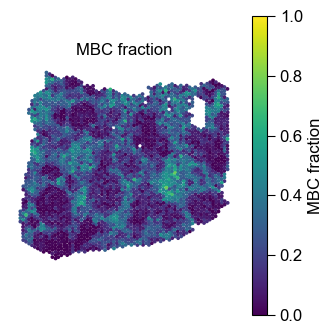

In [273]:
plot_spatial_continuous(
    values=spot_frac.loc["MBC"],
    tissue_pos=b1_tissue_position,
    title="MBC fraction",
    save_fig=True,
    outdir="./spatial_maps_B1"
)


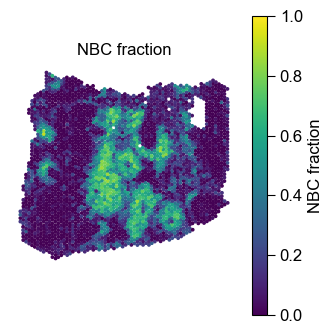

In [274]:
plot_spatial_continuous(
    values=spot_frac.loc["NBC"],
    tissue_pos=b1_tissue_position,
    title="NBC fraction",
    save_fig=True,
    outdir="./spatial_maps_B1"
)


In [275]:

def plot_spatial_pla(
    pla_vec: pd.Series,          # index=spot, value=PLA (e.g. CD20:CD32)
    tissue_pos: pd.DataFrame,    # Visium tissue_positions
    title: str,
    cmap="viridis",
    vmin=0,
    vmax=0.20,
    s=3,
    log1p=False,                 # optional, keep False since yours is normalized
    save_fig: bool = False,
    outdir: str = ".",
    dpi: int = 300,
):
    # --- align spots ---
    pla = pla_vec.copy()
    pla.index = pla.index.astype(str)

    tp = tissue_pos.loc[tissue_pos.index.intersection(pla.index)]
    pla = pla.loc[tp.index].astype(float)

    if log1p:
        pla = np.log1p(pla)

    x = tp["pxl_col_in_fullres"].values
    y = -tp["pxl_row_in_fullres"].values  # flip y-axis

    fig, ax = plt.subplots(figsize=(3.5, 3.5))
    sc = ax.scatter(
        x, y,
        c=pla.values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        s=s
    )
    ax.set_aspect("equal")
    ax.axis("off")

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(title)

    ax.set_title(title)
    fig.tight_layout()

    # --- save figure ---
    if save_fig:
        os.makedirs(outdir, exist_ok=True)
        safe_title = str(title).replace(" ", "_").replace("/", "_").replace(":", "_")
        fig.savefig(
            os.path.join(outdir, f"{safe_title}_spatial.svg"),
            dpi=dpi,
            bbox_inches="tight"
        )

    plt.show()


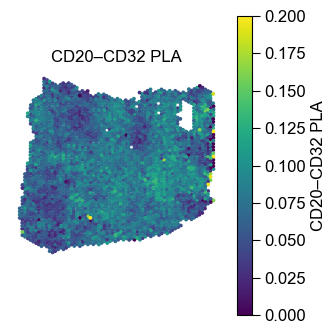

In [276]:
plot_spatial_pla(
    pla_vec=b1_pla_weight.loc["CD20:CD32"],
    tissue_pos=b1_tissue_position,
    title="CD20–CD32 PLA",
    save_fig=True,
    outdir="./spatial_pla_maps_B1"
)


In [277]:

def plot_pla_across_clusters_box(
    pla_pair: str,
    pla_weight_df: pd.DataFrame,      # rows=PLA pairs, cols=spots
    spot_to_cluster: pd.Series,       # index=spots, values=cluster names
    min_spots_per_cluster: int = 30,
    log1p: bool = False,              # keep False if already normalized
    figsize=(4, 3.5),
    save_fig: bool = False,
    outdir: str = ".",
    dpi: int = 300,
):
    # --- extract PLA vector ---
    pla = pla_weight_df.loc[pla_pair].copy()
    pla.index = pla.index.astype(str)

    stc = spot_to_cluster.copy()
    stc.index = stc.index.astype(str)

    common = pla.index.intersection(stc.index)
    df = pd.DataFrame({
        "pla": pla.loc[common].astype(float).values,
        "cluster": stc.loc[common].values
    }).dropna()

    if log1p:
        df["pla"] = np.log1p(df["pla"].values)

    # --- filter small clusters ---
    vc = df["cluster"].value_counts()
    keep = vc[vc >= min_spots_per_cluster].index
    df = df[df["cluster"].isin(keep)].copy()

    if df.empty:
        raise ValueError("No clusters left after filtering.")

    # --- order clusters by median PLA ---
    order = (
        df.groupby("cluster")["pla"]
          .median()
          .sort_values(ascending=False)
          .index.tolist()
    )

    # --- plot: box + jitter ---
    fig, ax = plt.subplots(figsize=figsize)

    sns.boxplot(
        data=df,
        x="cluster",
        y="pla",
        order=order,
        showfliers=False,
        linewidth=1,
        ax=ax
    )

    sns.stripplot(
        data=df,
        x="cluster",
        y="pla",
        order=order,
        size=2,
        alpha=0.35,
        jitter=0.25,
        ax=ax
    )

    ax.set_xticklabels(order, rotation=45, ha="right")
    ax.set_ylabel(f"{'log1p ' if log1p else ''}Fractional overlap score")
    ax.set_title(f"{pla_pair} across clusters")

    fig.tight_layout()

    # --- save figure ---
    if save_fig:
        os.makedirs(outdir, exist_ok=True)
        safe_pair = str(pla_pair).replace(" ", "_").replace("/", "_").replace(":", "_")
        fig.savefig(
            os.path.join(outdir, f"{safe_pair}.svg"),
            dpi=dpi,
            bbox_inches="tight"
        )

    plt.show()



/var/folders/zq/r1fxzh5j34100gjpvnw5chf40000gp/T/ipykernel_44223/1321851955.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=45, ha="right")


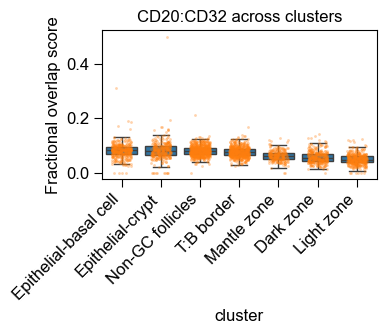

In [278]:
plot_pla_across_clusters_box(
    pla_pair="CD20:CD32",
    pla_weight_df=b1_pla_weight,
    spot_to_cluster=spot_to_cluster,
    save_fig=True,
    outdir="./boxplots_B1"
)
